# Signals: what changed today, and has that kind of change meant anything?

A **signal** is a rule that says "something unusual happened today". RADAR scores
three for each market:

| signal | the rule |
|---|---|
| change of state | the market's most probable state (calm, normal, turbulent) changed, and the new one is more than 70% probable |
| abnormal move | one hour's move was more than 5 times the usual size for the state the market was in |
| unusual news tone | the day's news tone was more than 2 standard deviations from the average of the year before |

The first two are shown in the app's feed. The third is scored here and kept as
evidence, but not shown as a signal: section 5 explains why.

A signal on its own is just an alarm going off. The useful question is the second one:
**when this alarm went off in the past, what happened next?** That is the signal's
**track record**, and this notebook builds it step by step.

The rule that keeps it honest: every past signal is found using **only what was known
that day**. The market states, in particular, come from a model that is fitted again
and again on earlier days only, never from today's model looking back.

Rebuild with `uv run python backend/scripts/build_notebooks.py 08_signals`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.pipelines import signals as job
from radar.signals import detect, track
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
pd.set_option("display.width", 200)
engine, universe = make_engine(), get_universe()
NAMES = {"BTC/USD": "Bitcoin", "GLD": "Gold", "SPY": "US stocks"}
TYPE = {"regime_change": "change of state", "abnormal_move": "abnormal move", "sentiment_shock": "unusual news tone"}

data = {}
with session_scope(engine) as session:
    for asset in universe.primary:
        hourly, days = job.hourly_returns(session, asset)
        data[asset.symbol] = {
            "asset": asset,
            "close": job.daily_close(session, asset),
            "states": job.states(session, asset),
            "hourly": hourly,
            "days": days,
            "found": job.occurrences(session, asset),
        }
    records, rows = job.build(session, universe)
every = sum(len(o) for d in data.values() for o in d["found"].values())
print(f"{every:,} past signals found across {len(data)} markets; {len(records)} kinds scored; {len(rows):,} shown in the feed")

773 past signals found across 3 markets; 21 kinds scored; 536 shown in the feed


## 1. Finding past signals without peeking

### Change of state

The market state for each past day comes from a **walk-forward** replay: every 63
trading days the state model is fitted on all the days before, then used for the next
63. So the state shown for a day in 2022 is what a model built in 2022 would have said.

Below: Bitcoin's price, shaded by the state known each day, with every change of state
marked.

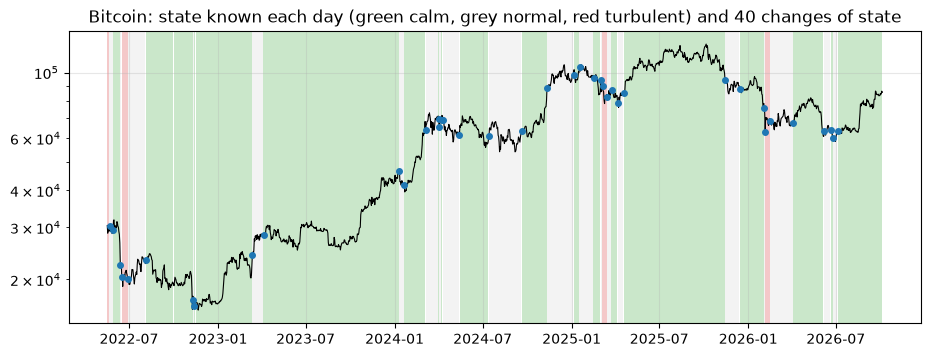

In [2]:
btc = data["BTC/USD"]
states = btc["states"]
close = btc["close"].reindex(states.index)
shade = {"calm": "tab:green", "normal": "lightgrey", "turbulent": "tab:red"}
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(close.index, close, color="black", linewidth=0.8)
run = (states["label"] != states["label"].shift()).cumsum()
for _, part in states.groupby(run):
    ax.axvspan(part.index[0], part.index[-1], color=shade[part["label"].iloc[0]], alpha=0.25, linewidth=0)
changes = btc["found"]["regime_change"]
ax.scatter([o.day for o in changes], close.reindex([o.day for o in changes]), color="tab:blue", s=16, zorder=3)
ax.set(title=f"Bitcoin: state known each day (green calm, grey normal, red turbulent) and {len(changes)} changes of state", yscale="log");

### Abnormal move

"Abnormal" is judged against the state the market was in. A 2% hour is ordinary in a
turbulent Bitcoin market and remarkable in a calm one. The usual size of an hour, for
each state, is measured on **earlier days only** and updated every day.

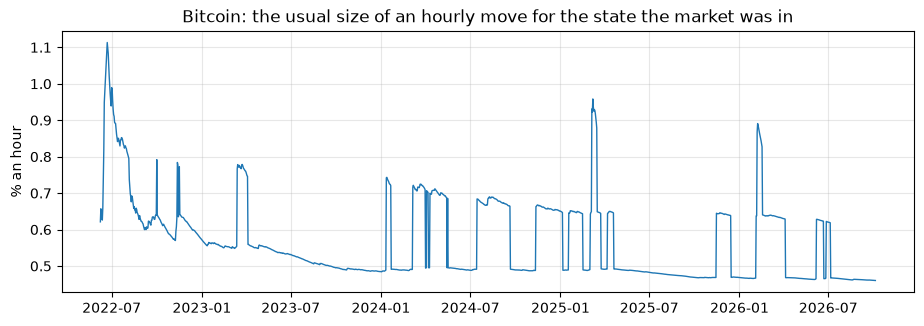

In [3]:
size = detect.usual_hourly_size(btc["hourly"], btc["days"], states["label"])
usual = size.groupby(btc["days"]).first().dropna()
fig, ax = plt.subplots()
ax.plot(usual.index, usual * 100, color="tab:blue", linewidth=1)
ax.set(title="Bitcoin: the usual size of an hourly move for the state the market was in", ylabel="% an hour");

### How high should the bar be?

The specification said 3 times the usual size. Counting how often each bar would have
fired settles it:

,3 times,4 times,5 times,6 times,7 times
Bitcoin,0.215,0.099,0.054,0.025,0.014
Gold,0.214,0.110,0.060,0.031,0.015
US stocks,0.173,0.075,0.040,0.023,0.011


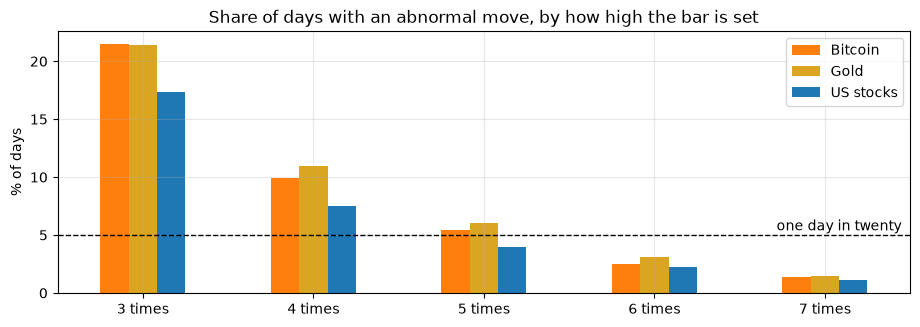

In [4]:
counts = {}
for symbol, d in data.items():
    n = len(d["states"])
    counts[NAMES[symbol]] = {
        f"{multiple} times": len(detect.abnormal_moves(d["hourly"], d["days"], d["states"]["label"], multiple=multiple)) / n
        for multiple in (3, 4, 5, 6, 7)
    }
rates = pd.DataFrame(counts).T
ax = (rates * 100).T.plot.bar(rot=0, color=["tab:orange", "goldenrod", "tab:blue"])
ax.axhline(5, color="black", linestyle="--", linewidth=1)
ax.text(4.45, 5.4, "one day in twenty", ha="right")
ax.set(title="Share of days with an abnormal move, by how high the bar is set", ylabel="% of days")
rates

At 3 times the rule fires on about **one day in five**. That is not "abnormal" in any
everyday sense. There are many hours in a day, each a chance to fire, and hourly moves
have far more extreme values than a bell curve would predict.

**The bar is set at 5 times**: about one day in twenty on each market, roughly once a
month. Higher bars leave too few past cases in each direction to judge.

The bar was chosen from this table alone, on **how often it fires**, before looking at
what followed at any bar other than the original 3. A bar picked because its track
record looked good would prove nothing.

### Unusual news tone

Each day's news tone is compared with the year before it (never including the day
itself).

In [5]:
found = {NAMES[s]: {TYPE[t]: len(o) for t, o in d["found"].items()} for s, d in data.items()}
pd.DataFrame(found).T

,change of state,abnormal move,unusual news tone
Bitcoin,40,87,87
Gold,96,133,40
US stocks,92,88,110


## 2. What happened next

For every past signal, take the market's return over the **next day** and the **next
week**, starting from the close of the signal's day (so nothing the signal was made
from is counted as its outcome). Do the same for **every day** as the baseline.

Two questions are asked of each kind of signal:

1. **Direction.** Did the market end higher afterwards more often than on any day?
2. **Size.** Whichever way it went, was the move bigger than on any day?

The chart shows the first question for the one-day horizon. Each bar is a kind of
signal; the line through it is the range the true share could plausibly lie in; the
tick is the same share for all days. **A signal has a directional edge only if its
whole range sits clear of the tick.**

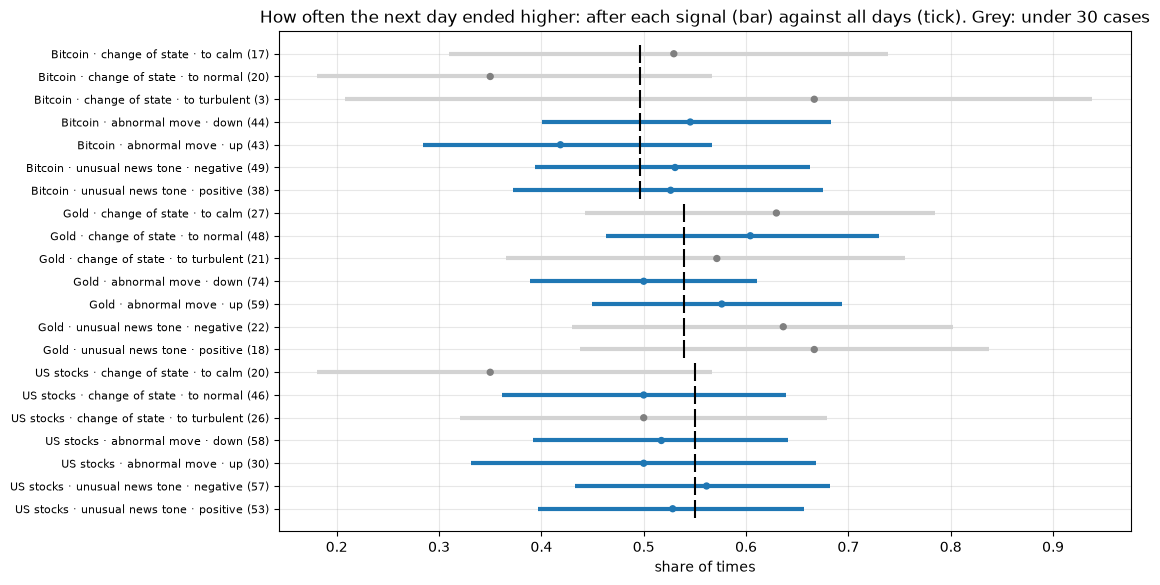

In [6]:
table = pd.DataFrame(
    [
        {
            "market": NAMES[r.symbol],
            "signal": TYPE[r.type],
            "kind": r.variant,
            "times": r.n,
            "up next day": r.horizons[0].signal.share_positive,
            "low": r.horizons[0].signal.share_low,
            "high": r.horizons[0].signal.share_high,
            "all days": r.horizons[0].baseline.share_positive,
            "direction": r.verdict,
            "typical next-day move": r.horizons[0].signal.mean_size,
            "on all days": r.horizons[0].baseline.mean_size,
            "size": r.size_verdict,
        }
        for r in records
    ]
)
fig, ax = plt.subplots(figsize=(11, 6.5))
labels = table["market"] + " · " + table["signal"] + " · " + table["kind"] + " (" + table["times"].astype(str) + ")"
y = np.arange(len(table))
enough = table["times"] >= track.MIN_OCCURRENCES
ax.hlines(y, table["low"], table["high"], color=np.where(enough, "tab:blue", "lightgrey"), linewidth=3)
ax.scatter(table["up next day"], y, color=np.where(enough, "tab:blue", "grey"), zorder=3, s=18)
ax.scatter(table["all days"], y, marker="|", color="black", s=160, zorder=4)
ax.set_yticks(y, labels, fontsize=8)
ax.invert_yaxis()
ax.set(title="How often the next day ended higher: after each signal (bar) against all days (tick). Grey: under 30 cases", xlabel="share of times");

In [7]:
table[["market", "signal", "kind", "times", "up next day", "all days", "direction"]]

,market,signal,kind,times,up next day,all days,direction
0,Bitcoin,change of state,to calm,17,0.529,0.496,not enough occurrences
1,Bitcoin,change of state,to normal,20,0.350,0.496,not enough occurrences
2,Bitcoin,change of state,to turbulent,3,0.667,0.496,not enough occurrences
3,Bitcoin,abnormal move,down,44,0.545,0.496,no measurable edge
4,Bitcoin,abnormal move,up,43,0.419,0.496,no measurable edge
5,Bitcoin,unusual news tone,negative,49,0.531,0.496,no measurable edge
6,Bitcoin,unusual news tone,positive,38,0.526,0.496,no measurable edge
7,Gold,change of state,to calm,27,0.630,0.539,not enough occurrences
8,Gold,change of state,to normal,48,0.604,0.539,no measurable edge
9,Gold,change of state,to turbulent,21,0.571,0.539,not enough occurrences


**Direction: nothing.** No signal on any market was followed by rises, or by falls,
more often than an ordinary day in a way that can be told apart from luck. Several
have too few cases to judge at all, and they are labelled that way and not guessed at.

### Correcting for looking at many things at once

With this many records and two horizons each, luck alone would make one or two look
special at the usual 5% bar. So the bar is raised for the whole family at once
(the Benjamini-Hochberg correction): a record keeps a verdict only if it would still
stand out given how many were looked at.

In [8]:
tested = [(r, h) for r in records for h in r.horizons if h.signal.n >= track.MIN_OCCURRENCES]
raw = sum(1 for _, h in tested if h.p_value is not None and h.p_value < 0.05)
kept = sum(1 for _, h in tested if h.verdict not in ("no measurable edge", "not enough occurrences"))
print(f"{len(tested)} comparisons had enough cases.")
print(f"Direction: {raw} looked special at the 5% bar before correction; {kept} remain after it.")
raw_size = sum(1 for _, h in tested if h.size_p_value is not None and h.size_p_value < 0.05)
kept_size = sum(1 for _, h in tested if h.size_verdict in ("followed by larger moves", "followed by smaller moves"))
print(f"Size:      {raw_size} looked special before correction; {kept_size} remain after it.")

24 comparisons had enough cases.
Direction: 0 looked special at the 5% bar before correction; 0 remain after it.
Size:      9 looked special before correction; 6 remain after it.


## 3. The size of the next move

The second question has a different answer for one market.

In [9]:
table[["market", "signal", "kind", "times", "typical next-day move", "on all days", "size"]]

,market,signal,kind,times,typical next-day move,on all days,size
0,Bitcoin,change of state,to calm,17,0.027,0.020,not enough occurrences
1,Bitcoin,change of state,to normal,20,0.028,0.020,not enough occurrences
2,Bitcoin,change of state,to turbulent,3,0.051,0.020,not enough occurrences
3,Bitcoin,abnormal move,down,44,0.021,0.020,no measurable difference
4,Bitcoin,abnormal move,up,43,0.027,0.020,no measurable difference
5,Bitcoin,unusual news tone,negative,49,0.025,0.020,no measurable difference
6,Bitcoin,unusual news tone,positive,38,0.019,0.020,no measurable difference
7,Gold,change of state,to calm,27,0.004,0.007,not enough occurrences
8,Gold,change of state,to normal,48,0.006,0.007,no measurable difference
9,Gold,change of state,to turbulent,21,0.010,0.007,not enough occurrences


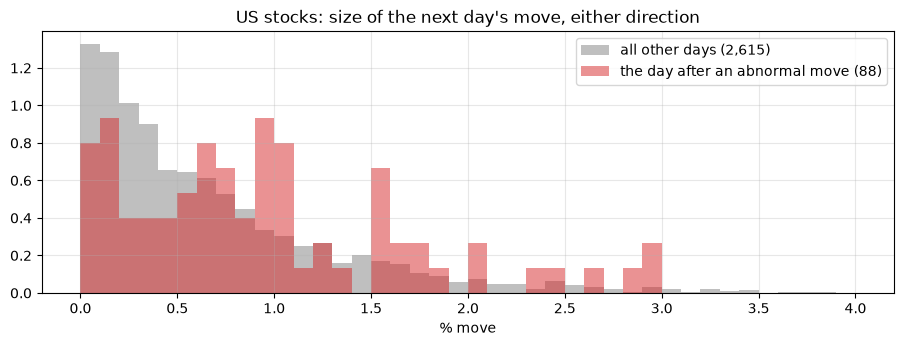

In [10]:
spy = data["SPY"]
forward = track.forward_returns(spy["close"], 1).abs().dropna() * 100
moves = [o.day for o in spy["found"]["abnormal_move"]]
after = forward[forward.index.isin(moves)]
other = forward[~forward.index.isin(moves)]
fig, ax = plt.subplots()
bins = np.linspace(0, 4, 41)
ax.hist(other, bins=bins, density=True, alpha=0.5, color="grey", label=f"all other days ({len(other):,})")
ax.hist(after, bins=bins, density=True, alpha=0.5, color="tab:red", label=f"the day after an abnormal move ({len(after):,})")
ax.set(title="US stocks: size of the next day's move, either direction", xlabel="% move")
ax.legend();

**Read this carefully.** After an abnormal hourly move in US stocks, and after a
downward one in gold, the next day and the next week tended to move more than usual,
in either direction. That is the well-known habit of rough days to cluster, seen from
another angle. It says "expect bigger swings", not "expect a fall" or "expect a rise".

Two cautions about this finding:

- **It was looked for after the direction test came up empty**, when the table of
  sizes showed a gap. It is corrected for the number of comparisons, but a result
  found this way deserves less trust than one planned in advance. The app says so.
- **It did not show up for Bitcoin**, where signal days and ordinary days were alike.

## 4. The no-lookahead checks

Rewrite the future and the past must not change.

In [11]:
with session_scope(engine) as session:
    from radar.pipelines.datasets import build_regime_observations

    observations = build_regime_observations(session, universe.get("SPY"))
original = detect.walk_forward_states(observations)
tampered = observations.copy()
cut = 2000
tampered.loc[tampered.index[cut:], "ret"] = 0.2
tampered.loc[tampered.index[cut:], "log_rv"] = 5.0
replayed = detect.walk_forward_states(tampered)
before = original.index < observations.index[cut]
# States must match exactly; probabilities to within rounding in the last decimal places.
assert (original["label"][before] == replayed["label"][before]).all()
assert np.allclose(original["probability"][before], replayed["probability"][before], atol=1e-9)
print(f"{before.sum():,} past states are identical after rewriting every day from row {cut:,} on")

close = spy["close"]
forward_1 = track.forward_returns(close, 1)
changed = close.copy()
changed.iloc[:1000] = 1.0
assert track.forward_returns(changed, 1).iloc[1000:].equals(forward_1.iloc[1000:])
print("A day's outcome uses nothing from before that day's close")

Model is not converging.  Current: 5914.830759994118 is not greater than 6704.391346589657. Delta is -789.5605865955386


Model is not converging.  Current: 5438.257869502827 is not greater than 6364.750534414388. Delta is -926.4926649115614


Model is not converging.  Current: 8843.030671943432 is not greater than 9648.448574422668. Delta is -805.4179024792356


Model is not converging.  Current: 13851.20292748518 is not greater than 13851.203135598498. Delta is -0.00020811331887671258


Model is not converging.  Current: 10614.279815598944 is not greater than 11342.996527733267. Delta is -728.7167121343227


Model is not converging.  Current: 10282.432743645417 is not greater than 13374.734013124626. Delta is -3092.3012694792087


Model is not converging.  Current: 11473.338474270226 is not greater than 16082.874516791693. Delta is -4609.536042521468


Model is not converging.  Current: 11351.905797267991 is not greater than 11950.669697262932. Delta is -598.7638999949413


1,500 past states are identical after rewriting every day from row 2,000 on
A day's outcome uses nothing from before that day's close


## 5. Why unusual news tone is not shown as a signal

Look back at the two tables: on every market, in both directions, unusual news tone
was followed by nothing that can be told apart from an ordinary day, in direction or
in size. This is the third test in this project to say the same thing (news tone does
not lead price; news does not improve the swings forecast).

An alert that has never meant anything is noise, and showing it beside alerts that do
carry information would make the whole feed less trustworthy. So it is **scored and
kept as evidence**, and **not shown in the feed or the daily brief**. If it starts to
mean something as more data arrives, its record will show it.

## What this means for the app

- The feed shows two kinds of signal: **changes of state** and **abnormal moves**.
  Each carries its track record.
- On direction, every record says **"no measurable edge"** or "not enough
  occurrences". That is the honest answer and the app shows it. A signal tells you
  something changed; it is not a prediction of direction.
- **Abnormal moves** now fire about once a month per market. In US stocks, and for
  falls in gold, they have been followed by larger moves than usual.
- **Changes of state** are rare (a few dozen in years of data per market), so most
  kinds cannot be judged yet. They will be as cases build up.

What the track record cannot tell you: anything about a future unlike these years, and
anything about a single signal. It describes what happened on average after many.